# VEATIC Evaluation Visualizations

This notebook parses the Round I evaluation summaries and constructs Polars data frames to drive Seaborn visualizations.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "docs").exists():
            return path
    raise FileNotFoundError(
        "Could not locate project root containing 'docs' directory."
    )


project_root = find_project_root(Path.cwd())
markdown_path = project_root / "docs/Stage VI - Evaluation/eval_res_round_i.md"
print(f"Using evaluation summary: {markdown_path}")

Using evaluation summary: /Users/desmondchoy/Projects/emo-rec/docs/Stage VI - Evaluation/eval_res_round_i.md


In [3]:
def extract_table_lines(markdown: str, heading: str) -> list[str]:
    lines = markdown.splitlines()
    start_idx = None
    for idx, line in enumerate(lines):
        if line.strip() == heading.strip():
            start_idx = idx
            break
    if start_idx is None:
        raise ValueError(f"Heading '{heading}' not found in markdown.")
    table_lines = []
    for line in lines[start_idx + 1 :]:
        if line.strip().startswith("|"):
            table_lines.append(line)
        elif table_lines:
            break
    if not table_lines:
        raise ValueError(f"No table found after heading '{heading}'.")
    return table_lines


def lines_to_polars_table(table_lines: list[str]) -> pl.DataFrame:
    rows = []
    headers = None
    for idx, raw_line in enumerate(table_lines):
        cells = [cell.strip() for cell in raw_line.strip().strip("|").split("|")]
        if idx == 0:
            headers = cells
            continue
        if all(cell.replace("-", "").strip() == "" for cell in cells):
            continue
        rows.append(cells)
    if headers is None:
        raise ValueError("Table header could not be determined.")
    return pl.DataFrame(rows, schema=headers, orient="row")


markdown_text = markdown_path.read_text(encoding="utf-8")

stabilized_lines = extract_table_lines(
    markdown_text, "### Stabilized MAE Summary (dataset-level)"
)
unstabilized_lines = extract_table_lines(
    markdown_text, "### Unstabilized MAE Summary (dataset-level)"
)

stabilized_df = lines_to_polars_table(stabilized_lines)
unstabilized_df = lines_to_polars_table(unstabilized_lines)

stabilized_df


Pathway,Valence Mean MAE,Valence 95% CI,Valence Median MAE,Arousal Mean MAE,Arousal 95% CI,Arousal Median MAE,Coverage Mean,Coverage Std
str,str,str,str,str,str,str,str,str
"""Face""","""0.208""","""0.185–0.234""","""0.181""","""0.168""","""0.148–0.189""","""0.152""","""0.861""","""0.171"""
"""Scene""","""0.238""","""0.210–0.268""","""0.221""","""0.203""","""0.178–0.230""","""0.162""","""–""","""–"""
"""Fusion""","""0.193""","""0.169–0.217""","""0.182""","""0.161""","""0.140–0.184""","""0.121""","""–""","""–"""


In [4]:
def clean_summary(df: pl.DataFrame, condition: str) -> pl.DataFrame:
    ci_cols = ["Valence 95% CI", "Arousal 95% CI"]
    numeric_cols = [
        "Valence Mean MAE",
        "Valence Median MAE",
        "Arousal Mean MAE",
        "Arousal Median MAE",
    ]
    coverage_cols = ["Coverage Mean", "Coverage Std"]
    dash_variants = ["–", "—", "−"]

    cleaned = df.with_columns(pl.lit(condition).alias("Condition"))

    cleaned = cleaned.with_columns(
        [
            pl.when(
                pl.col(col).is_null()
                | pl.col(col).str.strip_chars().is_in(dash_variants)
            )
            .then(None)
            .otherwise(
                pl.col(col)
                .str.replace("–", "-")
                .str.replace("—", "-")
                .str.replace("−", "-")
                .str.strip_chars()
            )
            .alias(col)
            for col in ci_cols
        ]
    )

    cleaned = cleaned.with_columns(
        [
            pl.when(
                pl.col(col).is_null()
                | pl.col(col).str.strip_chars().is_in(dash_variants)
            )
            .then(None)
            .otherwise(pl.col(col).str.strip_chars())
            .alias(col)
            for col in coverage_cols
        ]
    )

    cleaned = cleaned.with_columns(
        [pl.col(col).cast(pl.Float64) for col in numeric_cols]
    )
    cleaned = cleaned.with_columns(
        [pl.col(col).cast(pl.Float64) for col in coverage_cols]
    )

    for col in ci_cols:
        base = col.replace(" 95% CI", "")
        split_col = f"_{base.lower().replace(' ', '_')}_ci_parts"
        cleaned = cleaned.with_columns(
            pl.when(pl.col(col).is_null())
            .then(None)
            .otherwise(pl.col(col).str.split_exact("-", 1))
            .alias(split_col)
        )
        cleaned = cleaned.with_columns(
            [
                pl.col(split_col)
                .struct.field("field_0")
                .str.strip_chars()
                .cast(pl.Float64)
                .alias(f"{base} CI Low"),
                pl.col(split_col)
                .struct.field("field_1")
                .str.strip_chars()
                .cast(pl.Float64)
                .alias(f"{base} CI High"),
            ]
        )
        cleaned = cleaned.drop(split_col)

    return cleaned


In [5]:
if "summary_df" not in globals():
    markdown_text = markdown_path.read_text(encoding="utf-8")
    stabilized_lines = extract_table_lines(
        markdown_text, "### Stabilized MAE Summary (dataset-level)"
    )
    unstabilized_lines = extract_table_lines(
        markdown_text, "### Unstabilized MAE Summary (dataset-level)"
    )
    stabilized_df = lines_to_polars_table(stabilized_lines)
    unstabilized_df = lines_to_polars_table(unstabilized_lines)
    stabilized_clean = clean_summary(stabilized_df, "Stabilized")
    unstabilized_clean = clean_summary(unstabilized_df, "Unstabilized")
    summary_df = pl.concat([stabilized_clean, unstabilized_clean], how="vertical")

metrics_long = summary_df.melt(
    id_vars=["Pathway", "Condition"],
    value_vars=["Valence Mean MAE", "Arousal Mean MAE"],
    variable_name="Metric",
    value_name="MAE",
).with_columns(pl.col("Metric").str.replace(" Mean MAE", ""))

ci_low_long = summary_df.melt(
    id_vars=["Pathway", "Condition"],
    value_vars=["Valence CI Low", "Arousal CI Low"],
    variable_name="Metric",
    value_name="CI Low",
).with_columns(pl.col("Metric").str.replace(" CI Low", ""))

ci_high_long = summary_df.melt(
    id_vars=["Pathway", "Condition"],
    value_vars=["Valence CI High", "Arousal CI High"],
    variable_name="Metric",
    value_name="CI High",
).with_columns(pl.col("Metric").str.replace(" CI High", ""))

metrics_long = metrics_long.join(
    ci_low_long, on=["Pathway", "Condition", "Metric"], how="left"
).join(ci_high_long, on=["Pathway", "Condition", "Metric"], how="left")

metrics_long_pd = metrics_long.to_pandas()
metrics_long_pd


/var/folders/zj/jl8tq8jd44n2ykg30yhxlbmh0000gn/T/ipykernel_36000/2992683378.py:15: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  metrics_long = summary_df.melt(
/var/folders/zj/jl8tq8jd44n2ykg30yhxlbmh0000gn/T/ipykernel_36000/2992683378.py:22: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  ci_low_long = summary_df.melt(
/var/folders/zj/jl8tq8jd44n2ykg30yhxlbmh0000gn/T/ipykernel_36000/2992683378.py:29: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  ci_high_long = summary_df.melt(


,Pathway,Condition,Metric,MAE,CI Low,CI High
0,Face,Stabilized,Valence,0.208,0.185,0.234
1,Scene,Stabilized,Valence,0.238,0.210,0.268
2,Fusion,Stabilized,Valence,0.193,0.169,0.217
3,Face,Unstabilized,Valence,0.209,0.184,0.237
4,Scene,Unstabilized,Valence,0.239,0.210,0.268
5,Fusion,Unstabilized,Valence,0.193,0.171,0.217
6,Face,Stabilized,Arousal,0.168,0.148,0.189
7,Scene,Stabilized,Arousal,0.203,0.178,0.230
8,Fusion,Stabilized,Arousal,0.161,0.140,0.184
9,Face,Unstabilized,Arousal,0.168,0.147,0.189


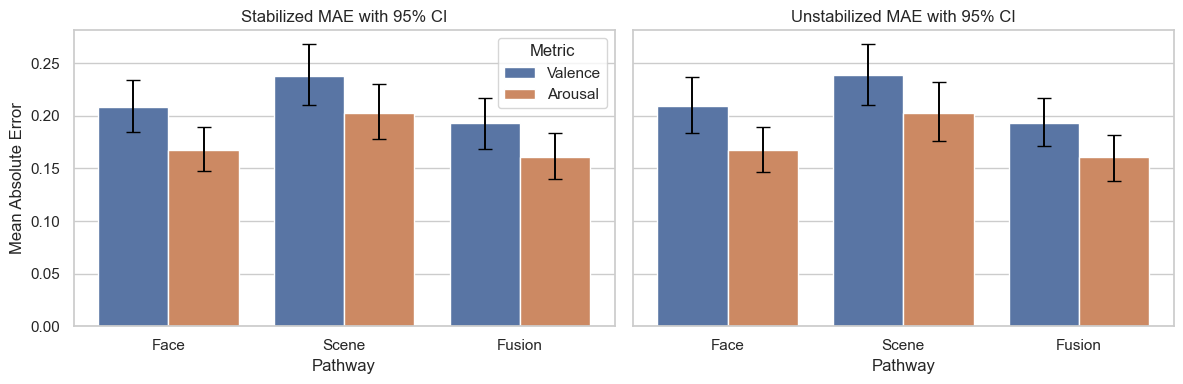

In [6]:
metrics_order = ["Valence", "Arousal"]
pathway_order = ["Face", "Scene", "Fusion"]
condition_order = list(metrics_long_pd["Condition"].unique())

fig, axes = plt.subplots(
    1, len(condition_order), figsize=(6 * len(condition_order), 4), sharey=True
)
if len(condition_order) == 1:
    axes = [axes]

for ax, condition in zip(axes, condition_order):
    subset = metrics_long_pd[metrics_long_pd["Condition"] == condition]
    sns.barplot(
        data=subset,
        x="Pathway",
        y="MAE",
        hue="Metric",
        order=pathway_order,
        hue_order=metrics_order,
        errorbar=None,
        ax=ax,
        palette="deep",
    )
    for metric, container in zip(metrics_order, ax.containers):
        metric_data = subset[subset["Metric"] == metric]
        metric_data = (
            metric_data.set_index("Pathway").reindex(pathway_order).reset_index()
        )
        ci_low = metric_data["CI Low"].to_numpy()
        ci_high = metric_data["CI High"].to_numpy()
        heights = metric_data["MAE"].to_numpy()
        errors = [heights - ci_low, ci_high - heights]
        x_positions = [
            patch.get_x() + patch.get_width() / 2 for patch in container.patches
        ]
        ax.errorbar(
            x=x_positions,
            y=heights,
            yerr=errors,
            fmt="none",
            ecolor="black",
            elinewidth=1.4,
            capsize=5,
        )
    ax.set_title(f"{condition} MAE with 95% CI")
    ax.set_xlabel("Pathway")
    ax.set_ylabel("Mean Absolute Error")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title="Metric")
for other_ax in axes[1:]:
    legend = other_ax.get_legend()
    if legend is not None:
        legend.remove()
plt.tight_layout()
plt.show()


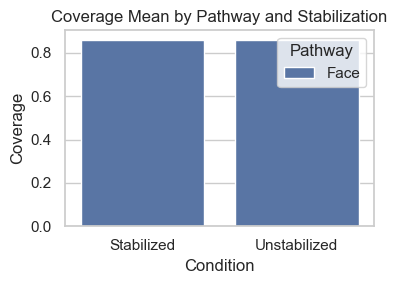

In [7]:
coverage_df = summary_df.select(["Pathway", "Condition", "Coverage Mean"]).drop_nulls(
    "Coverage Mean"
)
if coverage_df.height > 0:
    coverage_pd = coverage_df.to_pandas()
    plt.figure(figsize=(4, 3))
    sns.barplot(data=coverage_pd, x="Condition", y="Coverage Mean", hue="Pathway")
    plt.title("Coverage Mean by Pathway and Stabilization")
    plt.ylabel("Coverage")
    plt.tight_layout()
    plt.show()
else:
    print("No coverage data available in summary tables.")